# Notebook 04 – NLP Analysis of Therapist Comments

This notebook applies Natural Language Processing (NLP) techniques to the free-text comments recorded by therapists during the personalised storytelling intervention. The analysis aims to identify recurring linguistic patterns, sentiment, and behavioural themes within therapist observations.

The qualitative NLP findings will subsequently be examined alongside the participant clusters identified through K-Means clustering. This enables comparison of therapist observations across the two participant trajectory groups and provides a qualitative interpretation of the behavioural patterns identified in the quantitative clustering analysis.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [72]:
project_root = Path.cwd().parent

processed_data_folder = project_root / "data" / "processed"
outputs_folder = project_root / "outputs"
figures_folder = project_root / "figures"

In [73]:
cleaned_file = processed_data_folder / "cleaned_data.csv"

df = pd.read_csv(cleaned_file)

df.shape

(512, 75)

In [74]:
df["Submitted_by"].value_counts(dropna=False)

Submitted_by
T      256
P      240
P/C     16
Name: count, dtype: int64

## 4. Filter Therapist Records

The NLP analysis was restricted to therapist-generated observations to maintain consistency in the source and professional perspective of the qualitative data. Records submitted by parents or carers were therefore excluded from the NLP corpus.

In [75]:
therapist_df = df[df["Submitted_by"] == "T"].copy()

therapist_df.shape

(256, 75)

In [76]:
comment_cols = [
    col for col in therapist_df.columns
    if "Comment" in col
]

comment_cols

['Comment_Q1',
 'Comment_Q2',
 'Comment_Q3',
 'Comment_Q4',
 'Comment_Q5',
 'Comment_Q6',
 'Comment_Q7',
 'Comment_Q8',
 'Comment_Q9',
 'Comment_Q10',
 'Comment_Q11',
 'Comment_Q12',
 'Comment_Q13',
 'Comment_Q14',
 'Comment_Q15',
 'Comment_Q16',
 'Comment_Q17',
 'Comment_Q18',
 'Comment_Q20',
 'Comment_Q21',
 'Comment_Q22',
 'Comment_Q23',
 'Comment_Q24',
 'Comment_Q25',
 'Comment_Q26']

In [77]:
comment_counts = therapist_df[comment_cols].notna().sum()

comment_counts

Comment_Q1     24
Comment_Q2      5
Comment_Q3     36
Comment_Q4     11
Comment_Q5     16
Comment_Q6     10
Comment_Q7     15
Comment_Q8     21
Comment_Q9     36
Comment_Q10    21
Comment_Q11    19
Comment_Q12     3
Comment_Q13    17
Comment_Q14    15
Comment_Q15    28
Comment_Q16    14
Comment_Q17     3
Comment_Q18    15
Comment_Q20     8
Comment_Q21     6
Comment_Q22    12
Comment_Q23     6
Comment_Q24     9
Comment_Q25     7
Comment_Q26     2
dtype: int64

In [78]:
therapist_df["Number_of_comments"] = (
    therapist_df[comment_cols]
    .notna()
    .sum(axis=1)
)

therapist_df["Number_of_comments"].value_counts().sort_index()

Number_of_comments
0     121
1      45
2      33
3      23
4      16
5       7
6       4
7       3
8       2
9       1
10      1
Name: count, dtype: int64

In [79]:
therapist_df[comment_cols].stack().head(20)

16  Comment_Q2                                                                                                                                                                                              The participant appeared to understand the activity but showed no observable response.
    Comment_Q8                                                                                                                                                                                                                       Marked restlessness was observed, and cooperation was absent.
    Comment_Q15                                                                                                                                                                                                                                                                      Didn’t answer
17  Comment_Q1                                                                                                                 

In [80]:
therapist_df["combined_comments"] = (
    therapist_df[comment_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.strip()
)

In [81]:
"combined_comments" in therapist_df.columns

True

In [82]:
therapist_df.loc[
    therapist_df["combined_comments"] != "",
    ["Participant id", "Session number", "combined_comments"]
].head()

,Participant id,Session number,combined_comments
16,102,2,"The participant appeared to understand the activity but showed no observable response. Marked restlessness was observed, and cooperation was absent. Didn’t answer"
17,102,3,"The participant entered the classroom easily. With limited verbal ability, they repeated a small number of words. Responsiveness to the activity improved. The participant appeared to understand that the characters in the story represented themselves and family members. This was evident when the father’s name was mentioned, as the participant pointed outside the classroom. Due to the severity of the disorder, the participant has limited verbal abilities. At times, the participant verbally repeated “grandfather” and “grandmother.” The participant separated from the father without resistance or external pressure, which represents a significant improvement."
18,102,4,"The participant appeared to expect repetition of the previous story. When presented with a new story, cooperation decreased. Time was provided to allow adjustment to the new narrative. Voice imitation and intentional changes in tone during storytelling were used, resulting in laughter and increased attention Understanding of the core theme of the story remains limited. Progress is primarily observed in word repetition, though even these repetitions are not consistently used in appropriate contexts. Occasionally verbalized “grandfather.”"
19,102,5,"Notable progress was observed in independent separation from the parent and classroom entry. The participant laughed during storytelling, and overall cooperation increased. Verbal interaction began upon entering the classroom. The participant repeated the word “grandfather” while imitating the therapist’s voice. Although the repetition was non-functional, this attempt at verbal interaction was notable given the participant’s limited speech. Attention to the activity was acceptable. Initiation of activity was a significant observation, especially considering the absence of verbal cooperation in the first session. Repetition improved; however, contextual use remained impaired. For example, when asked, “What should you say when you see your grandmother?” the participant responded, “Hello grandfather.” A highly significant report from the father indicated that when told, “Put on your clothes, we’re going to listen to your story,” the participant prepared quickly and willingly. Increased use of story-related words was observed. Due to the depth of the disorder, sufficient mastery of this skill has not yet been achieved."
20,102,6,Decresed By 1 Minutes 45 sec


In [83]:
has_text = therapist_df["combined_comments"].str.strip().ne("")

print("Total therapist sessions:", len(therapist_df))
print("Sessions with comments:", has_text.sum())
print("Sessions without comments:", (~has_text).sum())

Total therapist sessions: 256
Sessions with comments: 134
Sessions without comments: 122


In [84]:
nlp_df = therapist_df.loc[
    therapist_df["combined_comments"].str.strip().ne(""),
    ["Participant id", "Session number", "combined_comments"]
].copy()

nlp_df.shape

(134, 3)

## 5. Explore the Therapist Text Corpus

Before NLP preprocessing, the availability and length of therapist-generated text were examined to assess the suitability of the qualitative data for subsequent text analysis.

In [85]:
nlp_df["word_count"] = (
    nlp_df["combined_comments"]
    .str.split()
    .str.len()
)

nlp_df["word_count"].describe()

count    134.000000
mean      33.828358
std       35.692194
min        1.000000
25%        9.000000
50%       23.000000
75%       44.250000
max      194.000000
Name: word_count, dtype: float64

In [86]:
nlp_df.loc[
    nlp_df["word_count"] <= 5,
    ["Participant id", "Session number", "word_count", "combined_comments"]
].sort_values("word_count")

,Participant id,Session number,word_count,combined_comments
100,109,6,1,Smiling
208,116,2,1,Smiling
212,116,6,1,Gestures
322,124,4,1,Smiling
386,128,4,1,Slow
256,119,2,2,1.5-2 Min
419,131,5,2,30 Seconds
180,114,6,2,Very Fast
421,131,7,2,10 seconds
177,114,3,3,Quick and complete


In [87]:
total_words = nlp_df["word_count"].sum()

print("Number of therapist text documents:", len(nlp_df))
print("Total words in corpus:", total_words)
print("Mean words per document:", round(nlp_df["word_count"].mean(), 2))
print("Median words per document:", nlp_df["word_count"].median())

Number of therapist text documents: 134
Total words in corpus: 4533
Mean words per document: 33.83
Median words per document: 23.0


## 6. Text Pre-processing

A separate cleaned version of the therapist text was created for NLP analysis while preserving the original comments. Initial preprocessing standardised letter case, removed unnecessary punctuation and non-alphabetic characters, and normalised whitespace. Further preprocessing decisions were evaluated separately to avoid removing behaviourally meaningful information from the relatively small corpus.

In [88]:
import re

In [89]:
def basic_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [90]:
nlp_df["cleaned_text"] = nlp_df["combined_comments"].apply(basic_clean_text)

In [91]:
nlp_df[
    ["combined_comments", "cleaned_text"]
].head(10)

,combined_comments,cleaned_text
16,"The participant appeared to understand the activity but showed no observable response. Marked restlessness was observed, and cooperation was absent. Didn’t answer",the participant appeared to understand the activity but showed no observable response marked restlessness was observed and cooperation was absent didn t answer
17,"The participant entered the classroom easily. With limited verbal ability, they repeated a small number of words. Responsiveness to the activity improved. The participant appeared to understand that the characters in the story represented themselves and family members. This was evident when the father’s name was mentioned, as the participant pointed outside the classroom. Due to the severity of the disorder, the participant has limited verbal abilities. At times, the participant verbally repeated “grandfather” and “grandmother.” The participant separated from the father without resistance or external pressure, which represents a significant improvement.",the participant entered the classroom easily with limited verbal ability they repeated a small number of words responsiveness to the activity improved the participant appeared to understand that the characters in the story represented themselves and family members this was evident when the father s name was mentioned as the participant pointed outside the classroom due to the severity of the disorder the participant has limited verbal abilities at times the participant verbally repeated grandfather and grandmother the participant separated from the father without resistance or external pressure which represents a significant improvement
18,"The participant appeared to expect repetition of the previous story. When presented with a new story, cooperation decreased. Time was provided to allow adjustment to the new narrative. Voice imitation and intentional changes in tone during storytelling were used, resulting in laughter and increased attention Understanding of the core theme of the story remains limited. Progress is primarily observed in word repetition, though even these repetitions are not consistently used in appropriate contexts. Occasionally verbalized “grandfather.”",the participant appeared to expect repetition of the previous story when presented with a new story cooperation decreased time was provided to allow adjustment to the new narrative voice imitation and intentional changes in tone during storytelling were used resulting in laughter and increased attention understanding of the core theme of the story remains limited progress is primarily observed in word repetition though even these repetitions are not consistently used in appropriate contexts occasionally verbalized grandfather
19,"Notable progress was observed in independent separation from the parent and classroom entry. The participant laughed during storytelling, and overall cooperation increased. Verbal interaction began upon entering the classroom. The participant repeated the word “grandfather” while imitating the therapist’s voice. Although the repetition was non-functional, this attempt at verbal interaction was notable given the participant’s limited speech. Attention to the activity was acceptable. Initiation of activity was a significant observation, especially considering the absence of verbal cooperation in the first session. Repetition improved; however, contextual use remained impaired. For example, when asked, “What should you say when you see your grandmother?” the participant responded, “Hello grandfather.” A highly significant report from the father indicated that when told, “Put on your clothes, we’re going to listen to your story,” the participant prepared quickly and willingly. Increased use of story-related words was observed. Due to the depth of the disorder, sufficient mastery of this skill has not yet been achieved.",notable progress was observed in independent separation from the parent and classroom entry the participant la

In [92]:
from collections import Counter

all_words = " ".join(nlp_df["cleaned_text"]).split()

word_freq = Counter(all_words)

word_freq.most_common(30)

[('the', 416),
 ('to', 134),
 ('and', 133),
 ('participant', 123),
 ('story', 111),
 ('of', 105),
 ('he', 98),
 ('in', 94),
 ('was', 91),
 ('a', 65),
 ('this', 60),
 ('with', 49),
 ('session', 44),
 ('his', 41),
 ('s', 40),
 ('that', 36),
 ('verbal', 32),
 ('observed', 31),
 ('new', 30),
 ('at', 26),
 ('it', 26),
 ('mother', 25),
 ('were', 24),
 ('not', 24),
 ('i', 24),
 ('increased', 23),
 ('activity', 22),
 ('during', 22),
 ('is', 22),
 ('stories', 22)]

### Stopword Identification

Initial word-frequency analysis showed that the therapist comment corpus contained many high-frequency grammatical words, such as *the*, *to*, *and*, and *of*, which provide limited semantic value for identifying behavioural patterns. Standard English stopwords were therefore identified for removal during text preprocessing.

At this stage, only standard English stopwords were considered. Domain-specific terms such as *participant*, *story*, *session*, and *therapist* were retained initially so that their frequency and relevance could be evaluated before deciding whether they should also be excluded from subsequent analyses.

In [93]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

len(stop_words)

318

In [94]:
def remove_stopwords(text):
    words = text.split()
    words = [
        word for word in words
        if word not in stop_words and word != "s"
    ]
    return " ".join(words)

nlp_df["text_no_stopwords"] = (
    nlp_df["cleaned_text"]
    .apply(remove_stopwords)
)

In [95]:
nlp_df[
    ["cleaned_text", "text_no_stopwords"]
].head(10)

,cleaned_text,text_no_stopwords
16,the participant appeared to understand the activity but showed no observable response marked restlessness was observed and cooperation was absent didn t answer,participant appeared understand activity showed observable response marked restlessness observed cooperation absent didn t answer
17,the participant entered the classroom easily with limited verbal ability they repeated a small number of words responsiveness to the activity improved the participant appeared to understand that the characters in the story represented themselves and family members this was evident when the father s name was mentioned as the participant pointed outside the classroom due to the severity of the disorder the participant has limited verbal abilities at times the participant verbally repeated grandfather and grandmother the participant separated from the father without resistance or external pressure which represents a significant improvement,participant entered classroom easily limited verbal ability repeated small number words responsiveness activity improved participant appeared understand characters story represented family members evident father mentioned participant pointed outside classroom severity disorder participant limited verbal abilities times participant verbally repeated grandfather grandmother participant separated father resistance external pressure represents significant improvement
18,the participant appeared to expect repetition of the previous story when presented with a new story cooperation decreased time was provided to allow adjustment to the new narrative voice imitation and intentional changes in tone during storytelling were used resulting in laughter and increased attention understanding of the core theme of the story remains limited progress is primarily observed in word repetition though even these repetitions are not consistently used in appropriate contexts occasionally verbalized grandfather,participant appeared expect repetition previous story presented new story cooperation decreased time provided allow adjustment new narrative voice imitation intentional changes tone storytelling used resulting laughter increased attention understanding core theme story remains limited progress primarily observed word repetition repetitions consistently used appropriate contexts occasionally verbalized grandfather
19,notable progress was observed in independent separation from the parent and classroom entry the participant laughed during storytelling and overall cooperation increased verbal interaction began upon entering the classroom the participant repeated the word grandfather while imitating the therapist s voice although the repetition was non functional this attempt at verbal interaction was notable given the participant s limited speech attention to the activity was acceptable initiation of activity was a significant observation especially considering the absence of verbal cooperation in the first session repetition improved however contextual use remained impaired for example when asked what should you say when you see your grandmother the participant responded hello grandfather a highly significant report from the father indicated that when told put on your clothes we re going to listen to your story the participant prepared quickly and willingly increased use of story related words was observed due to the depth of the disorder sufficient mastery of this skill has not yet been achieved,notable progress observed independent separation parent classroom entry participant laughed storytelling overall cooperation increased verbal interaction began entering classroom participant repeated word grandfather imitating therapist voice repetition non functional attempt verbal interaction notable given participant limited speech attention activity acceptable initiation activity significant observation especially considering absence verbal cooperation session repetition improved contextual use 

In [96]:
negation_words = ["not", "no", "never", "nor", "without"]

{word: word in stop_words for word in negation_words}

{'not': True, 'no': True, 'never': True, 'nor': True, 'without': True}

### Preserve Negation Terms

Negation terms were retained during stopword removal because they can substantially alter the meaning of behavioural observations. Words such as *not*, *no*, *never*, *nor*, and *without* were therefore excluded from the stopword list to reduce the risk of reversing the intended meaning of therapist comments.

In [97]:
negation_words = {"not", "no", "never", "nor", "without"}

stop_words = stop_words - negation_words

In [98]:
{word: word in stop_words for word in negation_words}

{'never': False, 'nor': False, 'no': False, 'without': False, 'not': False}

In [99]:
nlp_df["text_no_stopwords"] = (
    nlp_df["cleaned_text"]
    .apply(remove_stopwords)
)

In [100]:
nlp_df[
    nlp_df["cleaned_text"].str.contains(r"\b(not|no|never|nor|without)\b", regex=True)
][["cleaned_text", "text_no_stopwords"]].head(10)

C:\Users\puspi\AppData\Local\Temp\ipykernel_27996\1912149896.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  nlp_df["cleaned_text"].str.contains(r"\b(not|no|never|nor|without)\b", regex=True)


,cleaned_text,text_no_stopwords
16,the participant appeared to understand the activity but showed no observable response marked restlessness was observed and cooperation was absent didn t answer,participant appeared understand activity showed no observable response marked restlessness observed cooperation absent didn t answer
17,the participant entered the classroom easily with limited verbal ability they repeated a small number of words responsiveness to the activity improved the participant appeared to understand that the characters in the story represented themselves and family members this was evident when the father s name was mentioned as the participant pointed outside the classroom due to the severity of the disorder the participant has limited verbal abilities at times the participant verbally repeated grandfather and grandmother the participant separated from the father without resistance or external pressure which represents a significant improvement,participant entered classroom easily limited verbal ability repeated small number words responsiveness activity improved participant appeared understand characters story represented family members evident father mentioned participant pointed outside classroom severity disorder participant limited verbal abilities times participant verbally repeated grandfather grandmother participant separated father without resistance external pressure represents significant improvement
18,the participant appeared to expect repetition of the previous story when presented with a new story cooperation decreased time was provided to allow adjustment to the new narrative voice imitation and intentional changes in tone during storytelling were used resulting in laughter and increased attention understanding of the core theme of the story remains limited progress is primarily observed in word repetition though even these repetitions are not consistently used in appropriate contexts occasionally verbalized grandfather,participant appeared expect repetition previous story presented new story cooperation decreased time provided allow adjustment new narrative voice imitation intentional changes tone storytelling used resulting laughter increased attention understanding core theme story remains limited progress primarily observed word repetition repetitions not consistently used appropriate contexts occasionally verbalized grandfather
19,notable progress was observed in independent separation from the parent and classroom entry the participant laughed during storytelling and overall cooperation increased verbal interaction began upon entering the classroom the participant repeated the word grandfather while imitating the therapist s voice although the repetition was non functional this attempt at verbal interaction was notable given the participant s limited speech attention to the activity was acceptable initiation of activity was a significant observation especially considering the absence of verbal cooperation in the first session repetition improved however contextual use remained impaired for example when asked what should you say when you see your grandmother the participant responded hello grandfather a highly significant report from the father indicated that when told put on your clothes we re going to listen to your story the participant prepared quickly and willingly increased use of story related words was observed due to the depth of the disorder sufficient mastery of this skill has not yet been achieved,notable progress observed independent separation parent classroom entry participant laughed storytelling overall cooperation increased verbal interaction began entering classroom participant repeated word grandfather imitating therapist voice repetition non functional attempt verbal interaction notable given participant limited speech attention activity acceptable initiation activity significant observation especially considering absence verbal cooperation session repetition improved 

### 6.3 Word Frequency After Standard Stopword Removal

Following the removal of standard English stopwords while preserving negation terms, word frequencies were examined again to identify the most commonly occurring terms in the therapist comment corpus. This step was used to determine whether frequently occurring study-specific terms, such as *participant*, *story*, *session*, or *therapist*, should be treated as domain-specific stopwords in subsequent NLP analyses.

In [101]:
from collections import Counter

processed_words = " ".join(
    nlp_df["text_no_stopwords"]
).split()

processed_word_freq = Counter(processed_words)

processed_word_freq.most_common(30)

[('participant', 123),
 ('story', 111),
 ('session', 44),
 ('verbal', 32),
 ('observed', 31),
 ('new', 30),
 ('mother', 25),
 ('not', 24),
 ('increased', 23),
 ('activity', 22),
 ('stories', 22),
 ('cooperation', 20),
 ('smiling', 20),
 ('repeated', 19),
 ('previous', 19),
 ('showed', 18),
 ('decreased', 18),
 ('no', 17),
 ('listening', 16),
 ('improved', 15),
 ('level', 15),
 ('repetition', 14),
 ('learned', 14),
 ('read', 14),
 ('improvement', 13),
 ('therapist', 13),
 ('told', 13),
 ('sessions', 13),
 ('said', 13),
 ('initiation', 12)]

### 6.4 Domain-Specific Stopword Removal

The frequency analysis showed that several highly frequent terms primarily represented the context of the study rather than distinctive behavioural information. Terms such as *participant*, *story*, *stories*, *session*, *sessions*, and *therapist* were therefore treated as domain-specific stopwords for exploratory lexical analyses. Behaviourally informative terms, including those relating to verbal behaviour, cooperation, smiling, repetition, listening, improvement, and initiation, were retained.

In [102]:
domain_stopwords = {
    "participant",
    "story",
    "stories",
    "session",
    "sessions",
    "therapist"
}

def remove_domain_stopwords(text):
    words = text.split()
    words = [
        word for word in words
        if word not in domain_stopwords
    ]
    return " ".join(words)

nlp_df["final_processed_text"] = (
    nlp_df["text_no_stopwords"]
    .apply(remove_domain_stopwords)
)

In [103]:
final_words = " ".join(
    nlp_df["final_processed_text"]
).split()

final_word_freq = Counter(final_words)

final_word_freq.most_common(30)

[('verbal', 32),
 ('observed', 31),
 ('new', 30),
 ('mother', 25),
 ('not', 24),
 ('increased', 23),
 ('activity', 22),
 ('cooperation', 20),
 ('smiling', 20),
 ('repeated', 19),
 ('previous', 19),
 ('showed', 18),
 ('decreased', 18),
 ('no', 17),
 ('listening', 16),
 ('improved', 15),
 ('level', 15),
 ('repetition', 14),
 ('learned', 14),
 ('read', 14),
 ('improvement', 13),
 ('told', 13),
 ('said', 13),
 ('initiation', 12),
 ('stated', 12),
 ('limited', 11),
 ('attention', 11),
 ('remained', 11),
 ('participation', 11),
 ('responses', 11)]

### 7. Exploratory Word-Frequency Analysis

Following text preprocessing, the most frequently occurring content words in therapist observations were examined. This exploratory analysis provides an overview of recurring behavioural and interaction-related language within the qualitative corpus. Frequencies are interpreted descriptively and do not, by themselves, indicate whether a term was used in a positive or negative context.

In [104]:
word_freq_df = pd.DataFrame(
    final_word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

word_freq_df

,Word,Frequency
0,verbal,32
1,observed,31
2,new,30
3,mother,25
4,not,24
5,increased,23
6,activity,22
7,cooperation,20
8,smiling,20
9,repeated,19


### 7.1 Visualisation of Frequent Terms

The twenty most frequently occurring terms were visualised to provide a descriptive overview of the language used in therapist observations. The figure represents lexical frequency only; therefore, the presence of a term should not be interpreted as indicating a positive or negative behavioural outcome without considering its surrounding context.

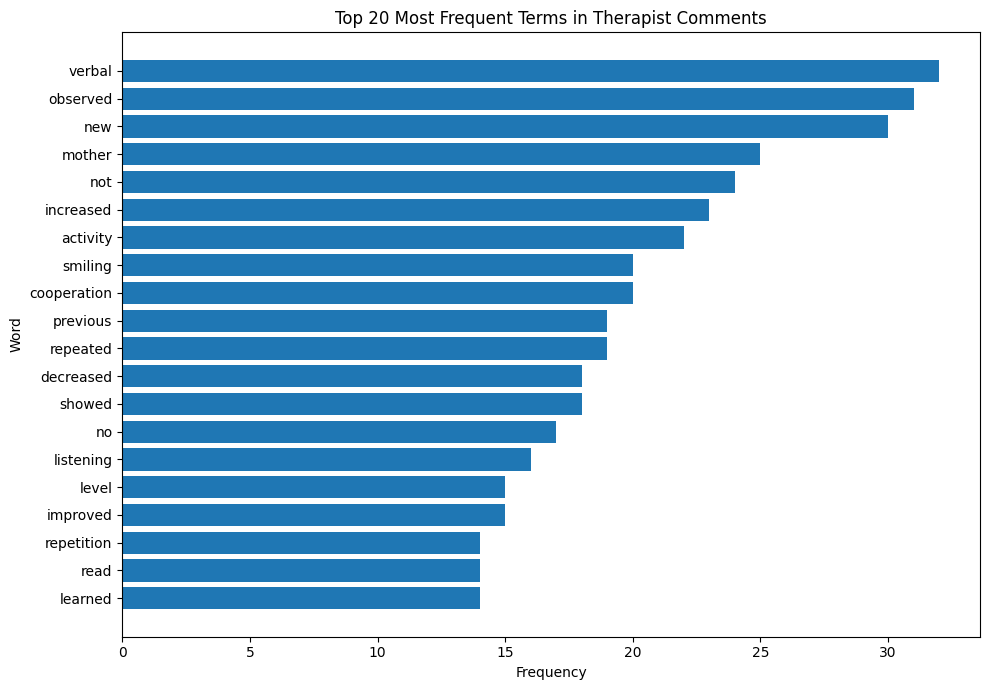

In [105]:
plt.figure(figsize=(10, 7))

plot_data = word_freq_df.sort_values("Frequency", ascending=True)

plt.barh(
    plot_data["Word"],
    plot_data["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Terms in Therapist Comments")

plt.tight_layout()
plt.show()

### 7.2 Refinement of Terms for Descriptive Visualisation

A further contextual review of the high-frequency terms identified several words that primarily reflected reporting style, information source, or general study context rather than specific behavioural content. These terms were retained in the underlying processed corpus where appropriate but excluded from the descriptive frequency visualisation to improve the interpretability of behaviourally relevant lexical patterns. Negation terms were also retained in the NLP corpus but excluded from isolated word-frequency visualisation because their meaning depends on surrounding words.

In [106]:
visualisation_exclusions = {
    "observed",
    "showed",
    "previous",
    "new",
    "mother",
    "activity",
    "level",
    "not",
    "no"
}

behaviour_word_freq = Counter(
    word for word in final_words
    if word not in visualisation_exclusions
)

behaviour_word_freq.most_common(20)

[('verbal', 32),
 ('increased', 23),
 ('cooperation', 20),
 ('smiling', 20),
 ('repeated', 19),
 ('decreased', 18),
 ('listening', 16),
 ('improved', 15),
 ('repetition', 14),
 ('learned', 14),
 ('read', 14),
 ('improvement', 13),
 ('told', 13),
 ('said', 13),
 ('initiation', 12),
 ('stated', 12),
 ('limited', 11),
 ('attention', 11),
 ('remained', 11),
 ('participation', 11)]

In [107]:
behaviour_word_freq_df = pd.DataFrame(
    behaviour_word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

behaviour_word_freq_df

,Word,Frequency
0,verbal,32
1,increased,23
2,cooperation,20
3,smiling,20
4,repeated,19
5,decreased,18
6,listening,16
7,improved,15
8,repetition,14
9,learned,14


In [108]:
visualisation_exclusions.add("seconds")

In [109]:
behaviour_word_freq = Counter(
    word for word in final_words
    if word not in visualisation_exclusions
)

behaviour_word_freq_df = pd.DataFrame(
    behaviour_word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

behaviour_word_freq_df

,Word,Frequency
0,verbal,32
1,increased,23
2,cooperation,20
3,smiling,20
4,repeated,19
5,decreased,18
6,listening,16
7,improved,15
8,repetition,14
9,learned,14


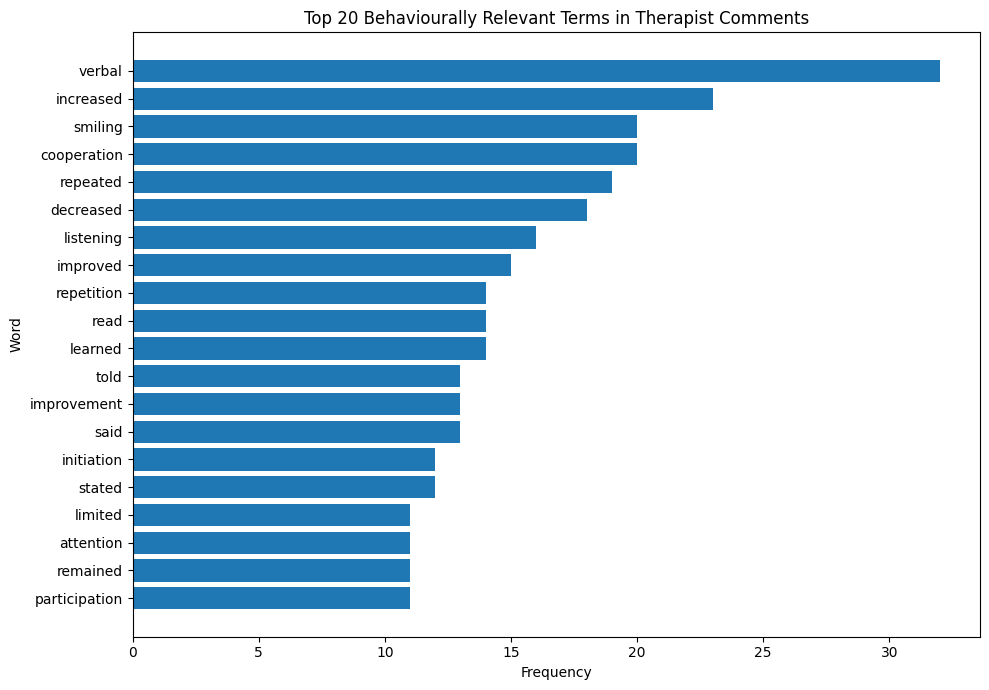

Figure saved to: c:\Users\puspi\OneDrive\Desktop\demo-testing\asd-interventions\figures\nlp_top20_behaviour_terms.png


In [110]:
plt.figure(figsize=(10, 7))

plot_data = behaviour_word_freq_df.sort_values(
    "Frequency",
    ascending=True
)

plt.barh(
    plot_data["Word"],
    plot_data["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Behaviourally Relevant Terms in Therapist Comments")

plt.tight_layout()

figure_path = figures_folder / "nlp_top20_behaviour_terms.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

In [111]:
figure_path.exists()

True

## 8. Bigram Analysis

To provide greater contextual information than individual word-frequency analysis, frequently occurring two-word combinations (bigrams) were examined within the processed therapist comments. Bigram analysis can reveal recurring behavioural expressions and relationships between terms that may not be apparent when words are analysed independently.

In [112]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=2
)

bigram_matrix = bigram_vectorizer.fit_transform(
    nlp_df["final_processed_text"]
)

bigram_frequencies = np.asarray(
    bigram_matrix.sum(axis=0)
).flatten()

bigram_df = pd.DataFrame({
    "Bigram": bigram_vectorizer.get_feature_names_out(),
    "Frequency": bigram_frequencies
}).sort_values(
    "Frequency",
    ascending=False
)

bigram_df.head(20)

,Bigram,Frequency
0,according mother,8
134,verbal communication,7
136,verbal participation,7
71,listening focus,7
100,real life,7
89,personal interests,6
34,did not,5
70,life situations,5
29,decreased seconds,5
10,attentive listening,5


In [113]:
print("Number of bigrams occurring in at least 2 documents:", len(bigram_df))

bigram_df["Frequency"].describe()

Number of bigrams occurring in at least 2 documents: 140


count    140.000000
mean       2.585714
std        1.217296
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        8.000000
Name: Frequency, dtype: float64

In [114]:
bigram_df.head(30)

,Bigram,Frequency
0,according mother,8
134,verbal communication,7
136,verbal participation,7
71,listening focus,7
100,real life,7
89,personal interests,6
34,did not,5
70,life situations,5
29,decreased seconds,5
10,attentive listening,5


In [115]:
bigram_visualisation_exclusions = {
    "according mother",
    "mother report",
    "mother reported",
    "decreased seconds",
    "participation observed",
    "improvement observed",
    "compared previous",
    "pink shoe",
    "read new",
    "said lets"
}

behaviour_bigram_df = (
    bigram_df[
        ~bigram_df["Bigram"].isin(bigram_visualisation_exclusions)
    ]
    .head(20)
    .reset_index(drop=True)
)

behaviour_bigram_df

,Bigram,Frequency
0,verbal communication,7
1,verbal participation,7
2,listening focus,7
3,real life,7
4,personal interests,6
5,did not,5
6,life situations,5
7,attentive listening,5
8,hands excitement,4
9,significant improvement,4


### 8.1 Visualisation of Behaviourally Relevant Bigrams

Frequently occurring behaviourally relevant bigrams were visualised to provide greater contextual detail than individual word frequencies. Contextual and reporting-specific phrases were excluded from the visualisation while remaining available in the underlying bigram dataset. The resulting bigrams provide an exploratory indication of recurring expressions relating to communication, engagement, learning, emotional expression, and behavioural response.

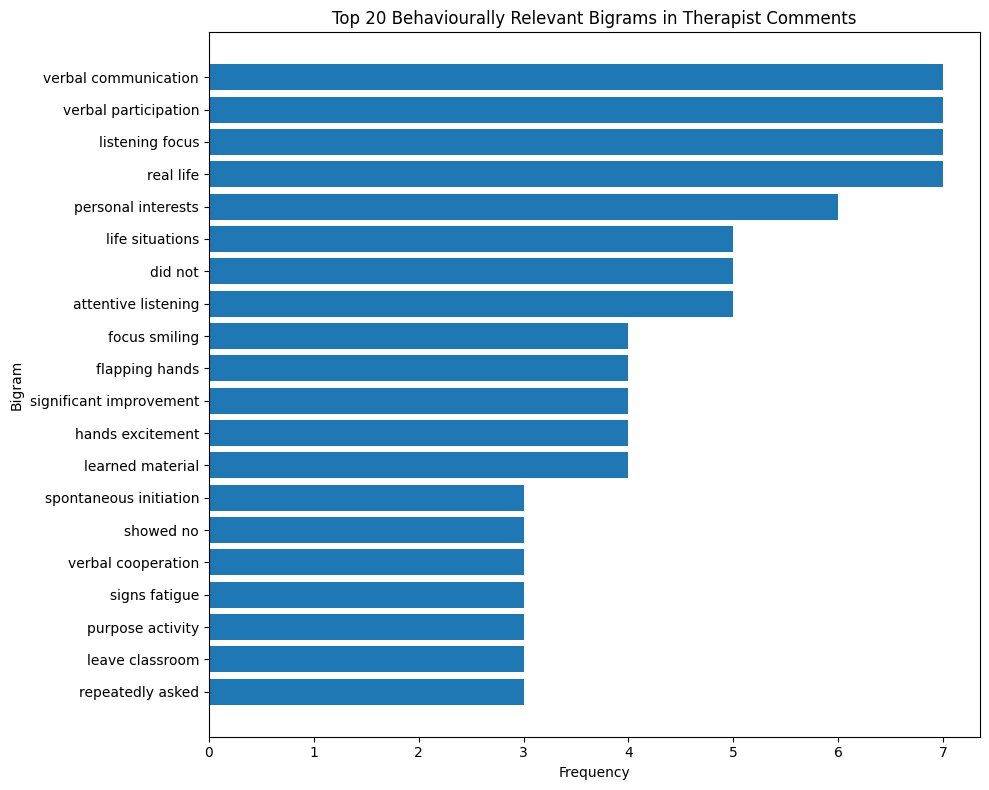

In [116]:
plt.figure(figsize=(10, 8))

plot_bigram_data = behaviour_bigram_df.sort_values(
    "Frequency",
    ascending=True
)

plt.barh(
    plot_bigram_data["Bigram"],
    plot_bigram_data["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Behaviourally Relevant Bigrams in Therapist Comments")

plt.tight_layout()
plt.show()

In [117]:
bigram_plot_exclusions = {"did not", "showed no"}

behaviour_bigram_plot_df = (
    behaviour_bigram_df[
        ~behaviour_bigram_df["Bigram"].isin(bigram_plot_exclusions)
    ]
    .copy()
)

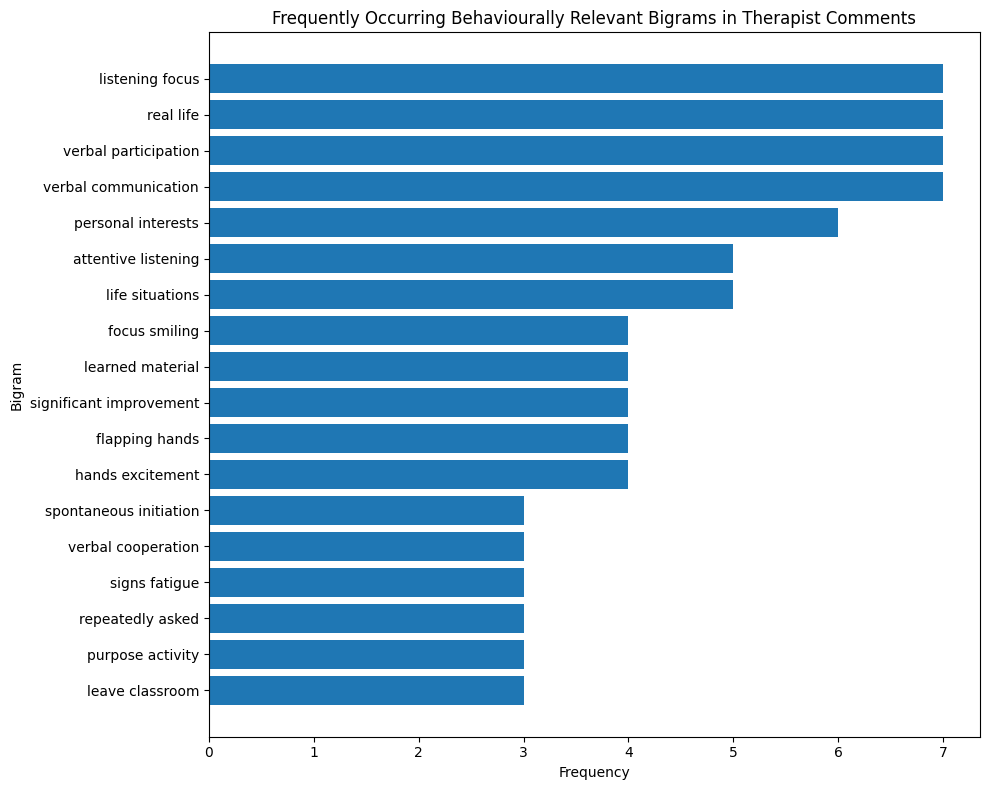

In [118]:
plt.figure(figsize=(10, 8))

plot_bigram_data = behaviour_bigram_plot_df.sort_values(
    "Frequency",
    ascending=True
)

plt.barh(
    plot_bigram_data["Bigram"],
    plot_bigram_data["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Frequently Occurring Behaviourally Relevant Bigrams in Therapist Comments")

plt.tight_layout()
plt.show()

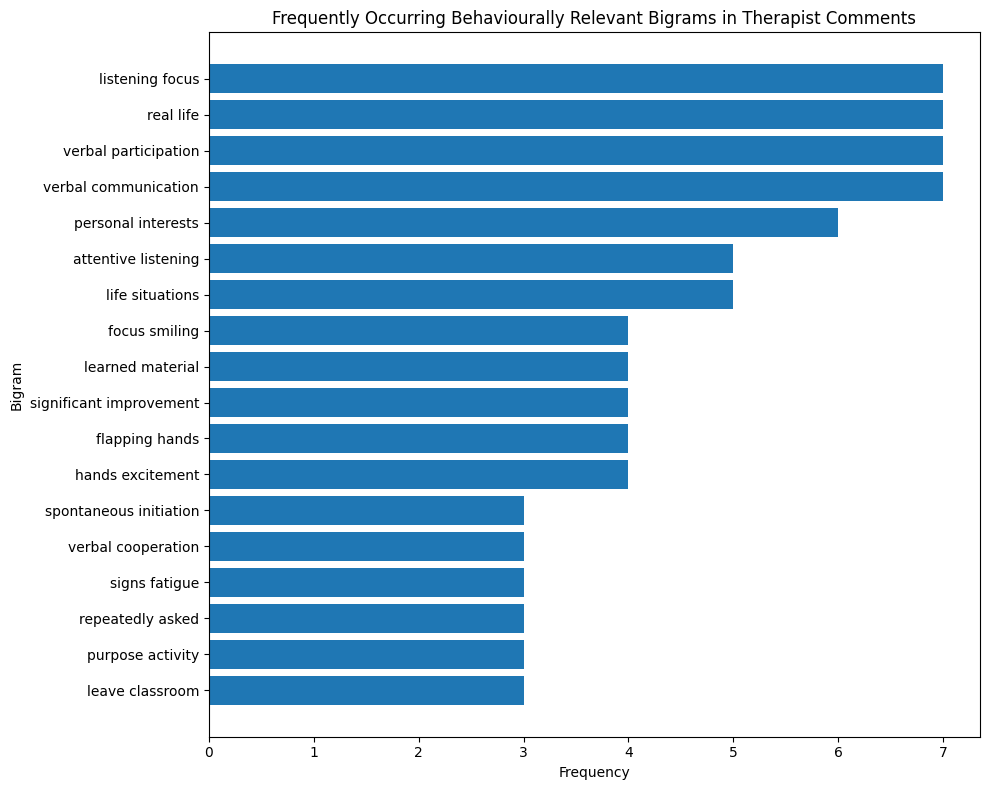

Figure saved to: c:\Users\puspi\OneDrive\Desktop\demo-testing\asd-interventions\figures\nlp_behavioural_bigrams.png


In [119]:
plt.figure(figsize=(10, 8))

plot_bigram_data = behaviour_bigram_plot_df.sort_values(
    "Frequency",
    ascending=True
)

plt.barh(
    plot_bigram_data["Bigram"],
    plot_bigram_data["Frequency"]
)

plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title(
    "Frequently Occurring Behaviourally Relevant Bigrams in Therapist Comments"
)

plt.tight_layout()

bigram_figure_path = figures_folder / "nlp_behavioural_bigrams.png"

plt.savefig(
    bigram_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", bigram_figure_path)

In [120]:
bigram_figure_path.exists()

True

### 8.2 Trigram Context Check

A limited trigram analysis was conducted to provide additional context for short negated or incomplete bigrams. This step was exploratory and was used to determine whether three-word expressions offered clearer behavioural meaning than two-word combinations.

In [121]:
trigram_vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    min_df=2
)

trigram_matrix = trigram_vectorizer.fit_transform(
    nlp_df["final_processed_text"]
)

trigram_frequencies = np.asarray(
    trigram_matrix.sum(axis=0)
).flatten()

trigram_df = pd.DataFrame({
    "Trigram": trigram_vectorizer.get_feature_names_out(),
    "Frequency": trigram_frequencies
}).sort_values(
    "Frequency",
    ascending=False
)

trigram_df.head(20)

,Trigram,Frequency
33,real life situations,5
0,according mother report,4
17,flapping hands excitement,4
26,listening focus smiling,4
12,cooperation completely absent,3
4,behavior exceeded social,2
2,applying real life,2
1,active attentive listening,2
7,change considered form,2
8,classroom decreased looked,2


**Interpretation.** The trigram analysis provided additional contextual information for several behavioural expressions identified in the bigram analysis. Examples included *real life situations*, *flapping hands excitement*, *active attentive listening*, *cooperation completely absent*, and *does not cooperate*. The latter expressions also demonstrated the importance of retaining negation terms during preprocessing. However, most trigrams occurred at relatively low frequencies and several represented fragmented expressions. Consequently, trigram analysis was retained as an exploratory contextual check rather than used as a primary quantitative representation of the therapist comments.

## 9. Sentiment Analysis

Sentiment analysis was used as an exploratory method to examine the emotional polarity of therapist-generated observations. However, therapist comments represent behavioural and clinical-style observations rather than conventional opinion or review text. Sentiment scores were therefore interpreted cautiously and were not treated as direct measures of participant improvement or intervention effectiveness.

The original therapist comments were retained for sentiment analysis because aggressive preprocessing, including stopword removal, can alter contextual and emotional meaning. In particular, negation terms such as *not*, *no*, and *never* are important for distinguishing positive and negative behavioural statements.

In [122]:
try:
    from nltk.sentiment import SentimentIntensityAnalyzer
    print("NLTK sentiment tools are available.")
except ImportError:
    print("NLTK is not installed.")

NLTK sentiment tools are available.


In [123]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [124]:
import nltk

print("NLTK version:", nltk.__version__)

NLTK version: 3.10.3


In [125]:
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\puspi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [126]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print("VADER sentiment analyser is ready.")

VADER sentiment analyser is ready.


### 9.1 Initial Validation of VADER on Therapist Comments

Before applying sentiment scoring to the full corpus, VADER was tested on a small sample of therapist comments. This qualitative validation was used to assess whether the sentiment scores appeared reasonable for behavioural observation text.

In [127]:
sample_comments = nlp_df[
    ["Participant id", "Session number", "combined_comments"]
].head(10).copy()

sample_comments["sentiment_scores"] = (
    sample_comments["combined_comments"]
    .apply(sia.polarity_scores)
)

sample_comments[
    ["Participant id", "Session number", "combined_comments", "sentiment_scores"]
]

,Participant id,Session number,combined_comments,sentiment_scores
16,102,2,"The participant appeared to understand the activity but showed no observable response. Marked restlessness was observed, and cooperation was absent. Didn’t answer","{'neg': 0.219, 'neu': 0.781, 'pos': 0.0, 'compound': -0.6808}"
17,102,3,"The participant entered the classroom easily. With limited verbal ability, they repeated a small number of words. Responsiveness to the activity improved. The participant appeared to understand that the characters in the story represented themselves and family members. This was evident when the father’s name was mentioned, as the participant pointed outside the classroom. Due to the severity of the disorder, the participant has limited verbal abilities. At times, the participant verbally repeated “grandfather” and “grandmother.” The participant separated from the father without resistance or external pressure, which represents a significant improvement.","{'neg': 0.084, 'neu': 0.763, 'pos': 0.153, 'compound': 0.7351}"
18,102,4,"The participant appeared to expect repetition of the previous story. When presented with a new story, cooperation decreased. Time was provided to allow adjustment to the new narrative. Voice imitation and intentional changes in tone during storytelling were used, resulting in laughter and increased attention Understanding of the core theme of the story remains limited. Progress is primarily observed in word repetition, though even these repetitions are not consistently used in appropriate contexts. Occasionally verbalized “grandfather.”","{'neg': 0.023, 'neu': 0.855, 'pos': 0.122, 'compound': 0.7964}"
19,102,5,"Notable progress was observed in independent separation from the parent and classroom entry. The participant laughed during storytelling, and overall cooperation increased. Verbal interaction began upon entering the classroom. The participant repeated the word “grandfather” while imitating the therapist’s voice. Although the repetition was non-functional, this attempt at verbal interaction was notable given the participant’s limited speech. Attention to the activity was acceptable. Initiation of activity was a significant observation, especially considering the absence of verbal cooperation in the first session. Repetition improved; however, contextual use remained impaired. For example, when asked, “What should you say when you see your grandmother?” the participant responded, “Hello grandfather.” A highly significant report from the father indicated that when told, “Put on your clothes, we’re going to listen to your story,” the participant prepared quickly and willingly. Increased use of story-related words was observed. Due to the depth of the disorder, sufficient mastery of this skill has not yet been achieved.","{'neg': 0.027, 'neu': 0.85, 'pos': 0.123, 'compound': 0.9231}"
20,102,6,Decresed By 1 Minutes 45 sec,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}"
21,102,7,"Positive affect was inferred through smiling and sustained eye contact Use of learned words was reported at home, though not in appropriate contexts.","{'neg': 0.0, 'neu': 0.761, 'pos': 0.239, 'compound': 0.765}"
22,102,8,"According to the mother, the participant greeted the grandmother at home during the week. After receiving positive reinforcement, the participant repeated this behavior several times. This method had a direct impact on reducing initial separation anxiety.","{'neg': 0.043, 'neu': 0.812, 'pos': 0.145, 'compound': 0.6124}"
23,102,9,"Improvement in therapist–participant rapport was observed, reflected in increased verbal participation. Following the previous session, the participant repeated story-related words while riding in the car.","{'neg': 0.0, 'neu': 0.819, 'pos': 0.181, 'compound': 0.6249}"
32,104,2,"The participant cooperated by memorizing and repeating answers; however, no conceptual understanding was observed. Due to ambiguity in the implementation procedure, the participant showed sign

In [128]:
sample_comments["compound"] = (
    sample_comments["combined_comments"]
    .apply(lambda text: sia.polarity_scores(text)["compound"])
)

pd.set_option("display.max_colwidth", None)

sample_comments[
    ["Participant id", "Session number", "combined_comments", "compound"]
]

,Participant id,Session number,combined_comments,compound
16,102,2,"The participant appeared to understand the activity but showed no observable response. Marked restlessness was observed, and cooperation was absent. Didn’t answer",-0.6808
17,102,3,"The participant entered the classroom easily. With limited verbal ability, they repeated a small number of words. Responsiveness to the activity improved. The participant appeared to understand that the characters in the story represented themselves and family members. This was evident when the father’s name was mentioned, as the participant pointed outside the classroom. Due to the severity of the disorder, the participant has limited verbal abilities. At times, the participant verbally repeated “grandfather” and “grandmother.” The participant separated from the father without resistance or external pressure, which represents a significant improvement.",0.7351
18,102,4,"The participant appeared to expect repetition of the previous story. When presented with a new story, cooperation decreased. Time was provided to allow adjustment to the new narrative. Voice imitation and intentional changes in tone during storytelling were used, resulting in laughter and increased attention Understanding of the core theme of the story remains limited. Progress is primarily observed in word repetition, though even these repetitions are not consistently used in appropriate contexts. Occasionally verbalized “grandfather.”",0.7964
19,102,5,"Notable progress was observed in independent separation from the parent and classroom entry. The participant laughed during storytelling, and overall cooperation increased. Verbal interaction began upon entering the classroom. The participant repeated the word “grandfather” while imitating the therapist’s voice. Although the repetition was non-functional, this attempt at verbal interaction was notable given the participant’s limited speech. Attention to the activity was acceptable. Initiation of activity was a significant observation, especially considering the absence of verbal cooperation in the first session. Repetition improved; however, contextual use remained impaired. For example, when asked, “What should you say when you see your grandmother?” the participant responded, “Hello grandfather.” A highly significant report from the father indicated that when told, “Put on your clothes, we’re going to listen to your story,” the participant prepared quickly and willingly. Increased use of story-related words was observed. Due to the depth of the disorder, sufficient mastery of this skill has not yet been achieved.",0.9231
20,102,6,Decresed By 1 Minutes 45 sec,0.0000
21,102,7,"Positive affect was inferred through smiling and sustained eye contact Use of learned words was reported at home, though not in appropriate contexts.",0.7650
22,102,8,"According to the mother, the participant greeted the grandmother at home during the week. After receiving positive reinforcement, the participant repeated this behavior several times. This method had a direct impact on reducing initial separation anxiety.",0.6124
23,102,9,"Improvement in therapist–participant rapport was observed, reflected in increased verbal participation. Following the previous session, the participant repeated story-related words while riding in the car.",0.6249
32,104,2,"The participant cooperated by memorizing and repeating answers; however, no conceptual understanding was observed. Due to ambiguity in the implementation procedure, the participant showed signs of mild frustration.",-0.6486
33,104,3,he participant attempted to imitate the therapist’s speech prosody and emotional tone. Placing the participant’s name in different situational contexts improved functional verbal usage. Verbal responses remained highly limited and were primarily repetitions of recorded auditory input.,0.3626


### 9.2 Session-Level Sentiment Scoring

Following the initial qualitative validation, VADER was applied to the original therapist comments at the session level. The compound sentiment score was retained as an exploratory measure of overall linguistic polarity, ranging from -1 (more negative) to +1 (more positive). These scores were interpreted as properties of the language used in therapist observations rather than direct measures of participant progress or intervention effectiveness.

In [129]:
nlp_df["sentiment_compound"] = (
    nlp_df["combined_comments"]
    .apply(lambda text: sia.polarity_scores(text)["compound"])
)

nlp_df["sentiment_compound"].describe()

count    134.000000
mean       0.283783
std        0.472006
min       -0.925300
25%        0.000000
50%        0.392050
75%        0.659700
max        0.991800
Name: sentiment_compound, dtype: float64

### 9.3 Sentiment Polarity Classification

For descriptive interpretation, session-level compound scores were categorised into positive, neutral, and negative linguistic polarity using conventional VADER thresholds. Scores of 0.05 or greater were classified as positive, scores of -0.05 or lower as negative, and scores between these thresholds as neutral. These categories represent the polarity of the language used in therapist comments and not direct classifications of participant outcomes.

In [130]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

nlp_df["sentiment_label"] = (
    nlp_df["sentiment_compound"]
    .apply(classify_sentiment)
)

nlp_df["sentiment_label"].value_counts()

sentiment_label
Positive    83
Neutral     32
Negative    19
Name: count, dtype: int64

In [131]:
sentiment_summary = (
    nlp_df["sentiment_label"]
    .value_counts()
    .reindex(["Positive", "Neutral", "Negative"])
    .to_frame("Count")
)

sentiment_summary["Percentage"] = (
    sentiment_summary["Count"] / len(nlp_df) * 100
).round(2)

sentiment_summary

,Count,Percentage
sentiment_label,,
Positive,83,61.94
Neutral,32,23.88
Negative,19,14.18


### 9.4 Distribution of Sentiment Polarity

The distribution of positive, neutral, and negative sentiment classifications was visualised to provide a descriptive overview of linguistic polarity across therapist-session comments.

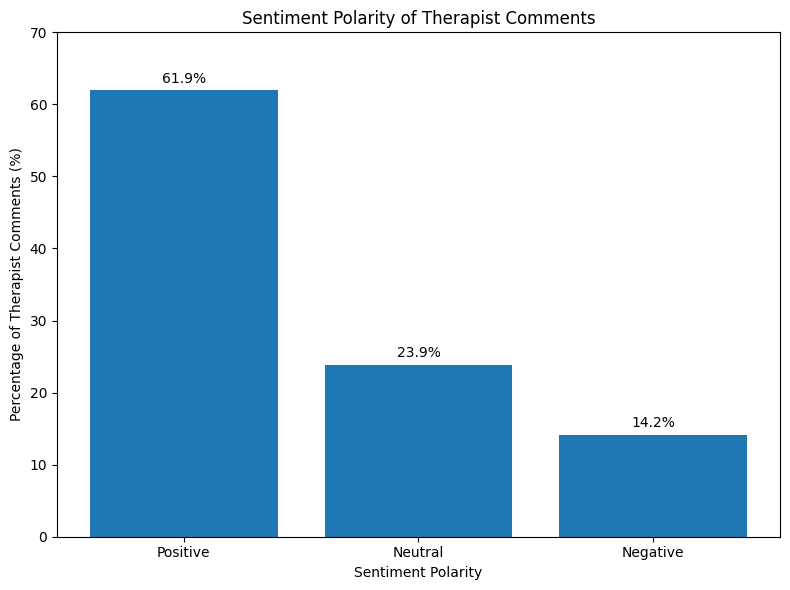

Figure saved to: c:\Users\puspi\OneDrive\Desktop\demo-testing\asd-interventions\figures\nlp_sentiment_polarity.png


In [132]:
plt.figure(figsize=(8, 6))

sentiment_plot = sentiment_summary.reset_index()

plt.bar(
    sentiment_plot["sentiment_label"],
    sentiment_plot["Percentage"]
)

plt.xlabel("Sentiment Polarity")
plt.ylabel("Percentage of Therapist Comments (%)")
plt.title("Sentiment Polarity of Therapist Comments")

plt.ylim(0, 70)

for i, value in enumerate(sentiment_plot["Percentage"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

sentiment_figure_path = figures_folder / "nlp_sentiment_polarity.png"

plt.savefig(
    sentiment_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", sentiment_figure_path)

In [133]:
sentiment_figure_path.exists()

True

### 9.5 Participant-Level Sentiment Aggregation

To align the NLP-derived sentiment measure with the participant-level quantitative dataset, session-level compound sentiment scores were aggregated by participant. The mean compound sentiment score was calculated across all therapist comments available for each participant. This participant-level measure represents the average linguistic polarity of therapist observations and should not be interpreted as a direct measure of behavioural improvement or intervention effectiveness.

In [134]:
participant_sentiment = (
    nlp_df.groupby("Participant id")
    .agg(
        Number_of_text_sessions=("sentiment_compound", "count"),
        Mean_sentiment_compound=("sentiment_compound", "mean")
    )
)

participant_sentiment.head(10)

,Number_of_text_sessions,Mean_sentiment_compound
Participant id,,
102,8,0.472013
104,7,0.233414
105,6,0.179550
106,7,-0.153443
107,4,0.105375
109,6,0.241100
110,6,0.587833
112,6,0.297600
113,7,0.419329


In [135]:
print("Number of participants with sentiment data:", len(participant_sentiment))

participant_sentiment.describe().round(3)

Number of participants with sentiment data: 23


,Number_of_text_sessions,Mean_sentiment_compound
count,23.000,23.000
mean,5.826,0.275
std,1.696,0.253
min,1.000,-0.331
25%,5.000,0.109
50%,6.000,0.297
75%,7.000,0.467
max,8.000,0.720


### 9.6 Integration with Participant-Level Quantitative Features

To support subsequent integration of the NLP-derived sentiment measure with the quantitative analysis, the previously generated participant-level feature dataset was loaded. Participant-level sentiment scores were then aligned using the participant identifier.

In [139]:
from pathlib import Path
import pandas as pd

participant_features_path = (
    Path("../data/processed/participant_features.csv")
)

participant_features = pd.read_csv(
    participant_features_path,
    index_col="Participant id"
)

participant_features.head()

,Number_of_sessions,Mean_engagement,Mean_emotional_connection,Mean_verbal_participation,Mean_attention,Mean_enjoyment,Mean_story_understanding,Mean_learning_application,Mean_confidence,Mean_generalisation,Mean_story_recall,Mean_reflection,Mean_real_life_connection,Mean_response_time_seconds,Mean_success_percentage
Participant id,,,,,,,,,,,,,,,
101,8,2.437500,2.125000,6.250000,2.562500,2.812500,2.571429,2.384615,2.000000,1.916667,2.083333,1.538462,1.461538,NaN,51.904762
102,8,1.750000,1.687500,4.000000,1.750000,2.250000,1.812500,1.437500,0.800000,0.600000,0.750000,0.250000,0.375000,160.0000,64.895833
104,8,2.187500,1.687500,5.333333,2.250000,2.266667,2.200000,1.666667,1.285714,0.933333,1.285714,0.666667,1.066667,6.2500,64.000000
105,8,3.562500,2.875000,7.625000,3.437500,3.187500,3.500000,2.000000,2.375000,2.125000,2.312500,1.875000,2.187500,42.1875,80.625000
106,8,1.533333,1.666667,3.800000,1.666667,1.500000,1.866667,1.000000,1.000000,0.600000,0.933333,0.466667,0.666667,77.5000,61.047619


In [140]:
[col for col in ["Number_of_text_sessions", "Mean_sentiment_compound"]
 if col in participant_features.columns]

[]

In [141]:
participant_features = participant_features.join(
    participant_sentiment,
    how="left"
)

participant_features[
    ["Number_of_text_sessions", "Mean_sentiment_compound"]
].head(10)

,Number_of_text_sessions,Mean_sentiment_compound
Participant id,,
101,NaN,NaN
102,8.0,0.472013
104,7.0,0.233414
105,6.0,0.179550
106,7.0,-0.153443
107,4.0,0.105375
109,6.0,0.241100
110,6.0,0.587833
111,NaN,NaN


In [142]:
participant_features[
    ["Number_of_text_sessions", "Mean_sentiment_compound"]
].isna().sum()

Number_of_text_sessions    9
Mean_sentiment_compound    9
dtype: int64

### 9.7 Saving the NLP-Enriched Participant Dataset

The participant-level sentiment variables were integrated with the previously generated quantitative feature dataset. Participants without available therapist-text data were retained with missing sentiment values rather than assigning artificial neutral scores. The enriched dataset was saved separately to preserve the original participant-level feature dataset.

In [143]:
nlp_participant_path = (
    Path("../data/processed/participant_features_with_nlp.csv")
)

participant_features.to_csv(
    nlp_participant_path,
    index=True
)

print("Saved to:", nlp_participant_path)

Saved to: ..\data\processed\participant_features_with_nlp.csv


In [144]:
print("File exists:", nlp_participant_path.exists())
print("Dataset shape:", participant_features.shape)

File exists: True
Dataset shape: (32, 17)


## 10. Final Validation and Outputs

Final checks were performed to verify the structure, missingness, and successful export of the NLP-enriched participant-level dataset. Missing sentiment values were retained for participants without available therapist-text observations.

In [145]:
print("Final dataset shape:", participant_features.shape)

print("\nMissing values:")
print(participant_features.isna().sum())

print("\nDuplicate participant IDs:")
print(participant_features.index.duplicated().sum())

print("\nSaved output:")
print(nlp_participant_path)
print("File exists:", nlp_participant_path.exists())

Final dataset shape: (32, 17)

Missing values:
Number_of_sessions            0
Mean_engagement               0
Mean_emotional_connection     0
Mean_verbal_participation     0
Mean_attention                0
Mean_enjoyment                0
Mean_story_understanding      0
Mean_learning_application     0
Mean_confidence               0
Mean_generalisation           0
Mean_story_recall             0
Mean_reflection               0
Mean_real_life_connection     0
Mean_response_time_seconds    5
Mean_success_percentage       1
Number_of_text_sessions       9
Mean_sentiment_compound       9
dtype: int64

Duplicate participant IDs:
0

Saved output:
..\data\processed\participant_features_with_nlp.csv
File exists: True


## 11. Summary

This notebook conducted an exploratory natural language processing (NLP) analysis of therapist-generated qualitative observations. Therapist comments were identified, combined at the session level, cleaned, and prepared for text analysis while preserving linguistically meaningful negation terms.

Descriptive lexical analysis was first conducted using unigram frequencies. Behaviourally relevant terms were visualised separately from generic reporting and contextual vocabulary. Bigram analysis was subsequently used to provide greater contextual information regarding recurring expressions in therapist observations, while a limited trigram analysis was used as an exploratory contextual check for more complex and negated expressions.

Exploratory sentiment analysis was conducted using VADER on the original therapist comments rather than heavily preprocessed text in order to preserve linguistic context. Of the 134 therapist-session text documents, 83 (61.94%) were classified as positive in linguistic polarity, 32 (23.88%) as neutral, and 19 (14.18%) as negative. These classifications represent the sentiment of the language used in therapist observations and were not interpreted as direct measures of participant improvement or intervention effectiveness.

Session-level sentiment scores were subsequently aggregated to the participant level. Sentiment data were available for 23 of the 32 participants, while participants without therapist-text observations were retained with missing values rather than being assigned artificial neutral scores.

Finally, the participant-level NLP measures were integrated with the quantitative feature dataset and exported as `participant_features_with_nlp.csv`. The resulting dataset contains 32 participants and 17 variables and is suitable for subsequent integrated quantitative and qualitative analysis.